# NB02 — Exploratory Data Analysis & Labeling
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251 — Govaere et al., *Science Translational Medicine*, 2020

---

**Purpose:** Apply the 4-class NAFLD staging label to every sample, perform
exploratory data analysis, and validate the resulting class distribution.

**4-Class Label Mapping:**

| Class | Label | Rule |
|-------|-------|------|
| 0 | Healthy Control | `disease == "Control"` |
| 1 | Simple Steatosis (NAFL) | NAFLD, Fibrosis F0–F1, NAS < 3 |
| 2 | NASH | NAFLD, Fibrosis F0–F1, NAS ≥ 3 |
| 3 | Advanced Fibrosis | NAFLD, Fibrosis F2–F4 (priority — always assigned if F ≥ 2) |

> **Priority rule:** If fibrosis stage ≥ 2, the sample is Class 3 regardless of NAS score.


## 1. Install Dependencies

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "umap-learn",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration

In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────
import pathlib

RANDOM_SEED = 42
REDOWNLOAD  = False  # True = re-download from GEO; False = read NB01 outputs

PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"

RESULTS_FIG.mkdir(parents=True, exist_ok=True)

# Class names & colors (consistent palette for all downstream notebooks)
CLASS_NAMES  = {0: "Healthy", 1: "Steatosis", 2: "NASH", 3: "Adv. Fibrosis"}
CLASS_COLORS = {0: "#2ecc71", 1: "#3498db", 2: "#e67e22", 3: "#e74c3c"}

# Figure settings
DPI = 300

print(f"Project root: {PROJECT_ROOT}")
print(f"REDOWNLOAD  : {REDOWNLOAD}")


Project root: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset
REDOWNLOAD  : False


## 3. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings

np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("All imports loaded.")


All imports loaded.


## 4. Load Data

Load the raw expression matrix and metadata saved by NB01.  
If `REDOWNLOAD = True`, re-download from GEO (not implemented here — run NB01 first).


In [4]:
if REDOWNLOAD:
    raise NotImplementedError(
        "Set REDOWNLOAD=False and run NB01 first to generate the input files, "
        "or copy the GEO download logic from NB01."
    )

# Load expression matrix (genes × samples)
expr_path = DATA_RAW / "expression_matrix_raw.csv"
assert expr_path.exists(), f"Missing: {expr_path}. Run NB01 first."
expression = pd.read_csv(expr_path, index_col=0)
print(f"Expression matrix: {expression.shape} (genes × samples)")

# Load metadata
meta_path = DATA_META / "metadata_raw.csv"
assert meta_path.exists(), f"Missing: {meta_path}. Run NB01 first."
metadata = pd.read_csv(meta_path)
print(f"Metadata: {metadata.shape}")
print(f"Columns: {metadata.columns.tolist()}")
metadata.head()


Expression matrix: (42584, 216) (genes × samples)
Metadata: (216, 6)
Columns: ['sample_id', 'nas score', 'fibrosis stage', 'group in paper', 'disease', 'stage']


,sample_id,nas score,fibrosis stage,group in paper,disease,stage
0,GSM3998167,4,2,NASH_F2,NAFLD,early
1,GSM3998168,7,3,NASH_F3,NAFLD,moderate
2,GSM3998169,7,2,NASH_F2,NAFLD,early
3,GSM3998170,6,3,NASH_F3,NAFLD,moderate
4,GSM3998171,5,0,NASH_F0-F1,NAFLD,early


## 5. Apply 4-Class Label Mapping

**Mapping logic (applied in priority order):**
1. `disease == "Control"` → **Class 0** (Healthy)
2. `fibrosis_stage ≥ 2` → **Class 3** (Advanced Fibrosis) — *priority rule*
3. `NAS ≥ 3` and `fibrosis_stage ∈ {0, 1}` → **Class 2** (NASH)
4. Remaining NAFLD with `fibrosis_stage ∈ {0, 1}` → **Class 1** (Simple Steatosis / NAFL)


In [5]:
def assign_nafld_stage(row):
    """Assign 4-class NAFLD stage label based on clinical metadata.

    Priority rule: fibrosis ≥ 2 always gets Class 3 regardless of NAS.
    """
    disease  = str(row.get("disease", "")).strip()
    nas      = row.get("nas score", np.nan)
    fibrosis = row.get("fibrosis stage", np.nan)

    # Class 0: Healthy controls
    if disease.lower() == "control":
        return 0

    # Class 3: Advanced Fibrosis (priority — F ≥ 2)
    if pd.notna(fibrosis) and fibrosis >= 2:
        return 3

    # Class 2: NASH (NAS ≥ 3, F0–F1)
    if pd.notna(nas) and nas >= 3:
        return 2

    # Class 1: Simple Steatosis (remaining NAFLD, F0–F1, NAS < 3)
    return 1


metadata["nafld_stage"] = metadata.apply(assign_nafld_stage, axis=1)
metadata["stage_name"]  = metadata["nafld_stage"].map(CLASS_NAMES)

# Report distribution
print("=" * 50)
print("4-CLASS LABEL DISTRIBUTION")
print("=" * 50)
class_counts = metadata["nafld_stage"].value_counts().sort_index()
for cls_id, count in class_counts.items():
    pct = count / len(metadata) * 100
    name = CLASS_NAMES[cls_id]
    print(f"  Class {cls_id} ({name:15s}): {count:4d} samples ({pct:5.1f}%)")
print(f"  {'Total':23s}: {len(metadata):4d}")
print("=" * 50)

# Warn if any class < 15
for cls_id, count in class_counts.items():
    if count < 15:
        print(f"  [!] WARNING: Class {cls_id} ({CLASS_NAMES[cls_id]}) has only "
              f"{count} samples — consider fallback plan.")


4-CLASS LABEL DISTRIBUTION
  Class 0 (Healthy        ):   10 samples (  4.6%)
  Class 1 (Steatosis      ):   30 samples ( 13.9%)
  Class 2 (NASH           ):   55 samples ( 25.5%)
  Class 3 (Adv. Fibrosis  ):  121 samples ( 56.0%)
  Total                  :  216
  [!] WARNING: Class 0 (Healthy) has only 10 samples — consider fallback plan.


## 6. Ambiguous Sample Resolution

In [6]:
# Cross-tabulate group_in_paper vs our assigned stage to verify mapping
crosstab = pd.crosstab(
    metadata["group in paper"],
    metadata["stage_name"],
    margins=True
)
print("Cross-tabulation: 'group in paper' vs assigned NAFLD stage:")
print(crosstab.to_string())
print()

# Identify any samples where group_in_paper and our label might disagree
# This documents the mapping logic and ensures transparency
print("Mapping resolution:")
print("  - 'control' → Class 0 (Healthy)")
print("  - 'NAFL' with F0-F1 → Class 1 (Steatosis) or Class 3 if F≥2")
print("  - 'NASH_F0-F1' → Class 2 (NASH)")
print("  - 'NASH_F2', 'NASH_F3', 'NASH_F4' → Class 3 (Adv. Fibrosis)")
print()
print("Any NAFL samples with fibrosis ≥ 2 are reassigned to Class 3 by priority rule.")

# Check for NAFL samples pushed to Class 3
nafl_as_fib = metadata[
    (metadata["group in paper"] == "NAFL") & (metadata["nafld_stage"] == 3)
]
if len(nafl_as_fib) > 0:
    print(f"  [!] {len(nafl_as_fib)} NAFL sample(s) reassigned to Class 3 (fibrosis ≥ 2)")
else:
    print("  [OK] No NAFL samples reassigned to Class 3")


Cross-tabulation: 'group in paper' vs assigned NAFLD stage:
stage_name      Adv. Fibrosis  Healthy  NASH  Steatosis  All
group in paper                                              
NAFL                        0        0    21         30   51
NASH_F0-F1                  0        0    34          0   34
NASH_F2                    53        0     0          0   53
NASH_F3                    54        0     0          0   54
NASH_F4                    14        0     0          0   14
control                     0       10     0          0   10
All                       121       10    55         30  216

Mapping resolution:
  - 'control' → Class 0 (Healthy)
  - 'NAFL' with F0-F1 → Class 1 (Steatosis) or Class 3 if F≥2
  - 'NASH_F0-F1' → Class 2 (NASH)
  - 'NASH_F2', 'NASH_F3', 'NASH_F4' → Class 3 (Adv. Fibrosis)

Any NAFL samples with fibrosis ≥ 2 are reassigned to Class 3 by priority rule.
  [OK] No NAFL samples reassigned to Class 3


## 7. EDA Visualizations
### 7.1 Class Distribution

d:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


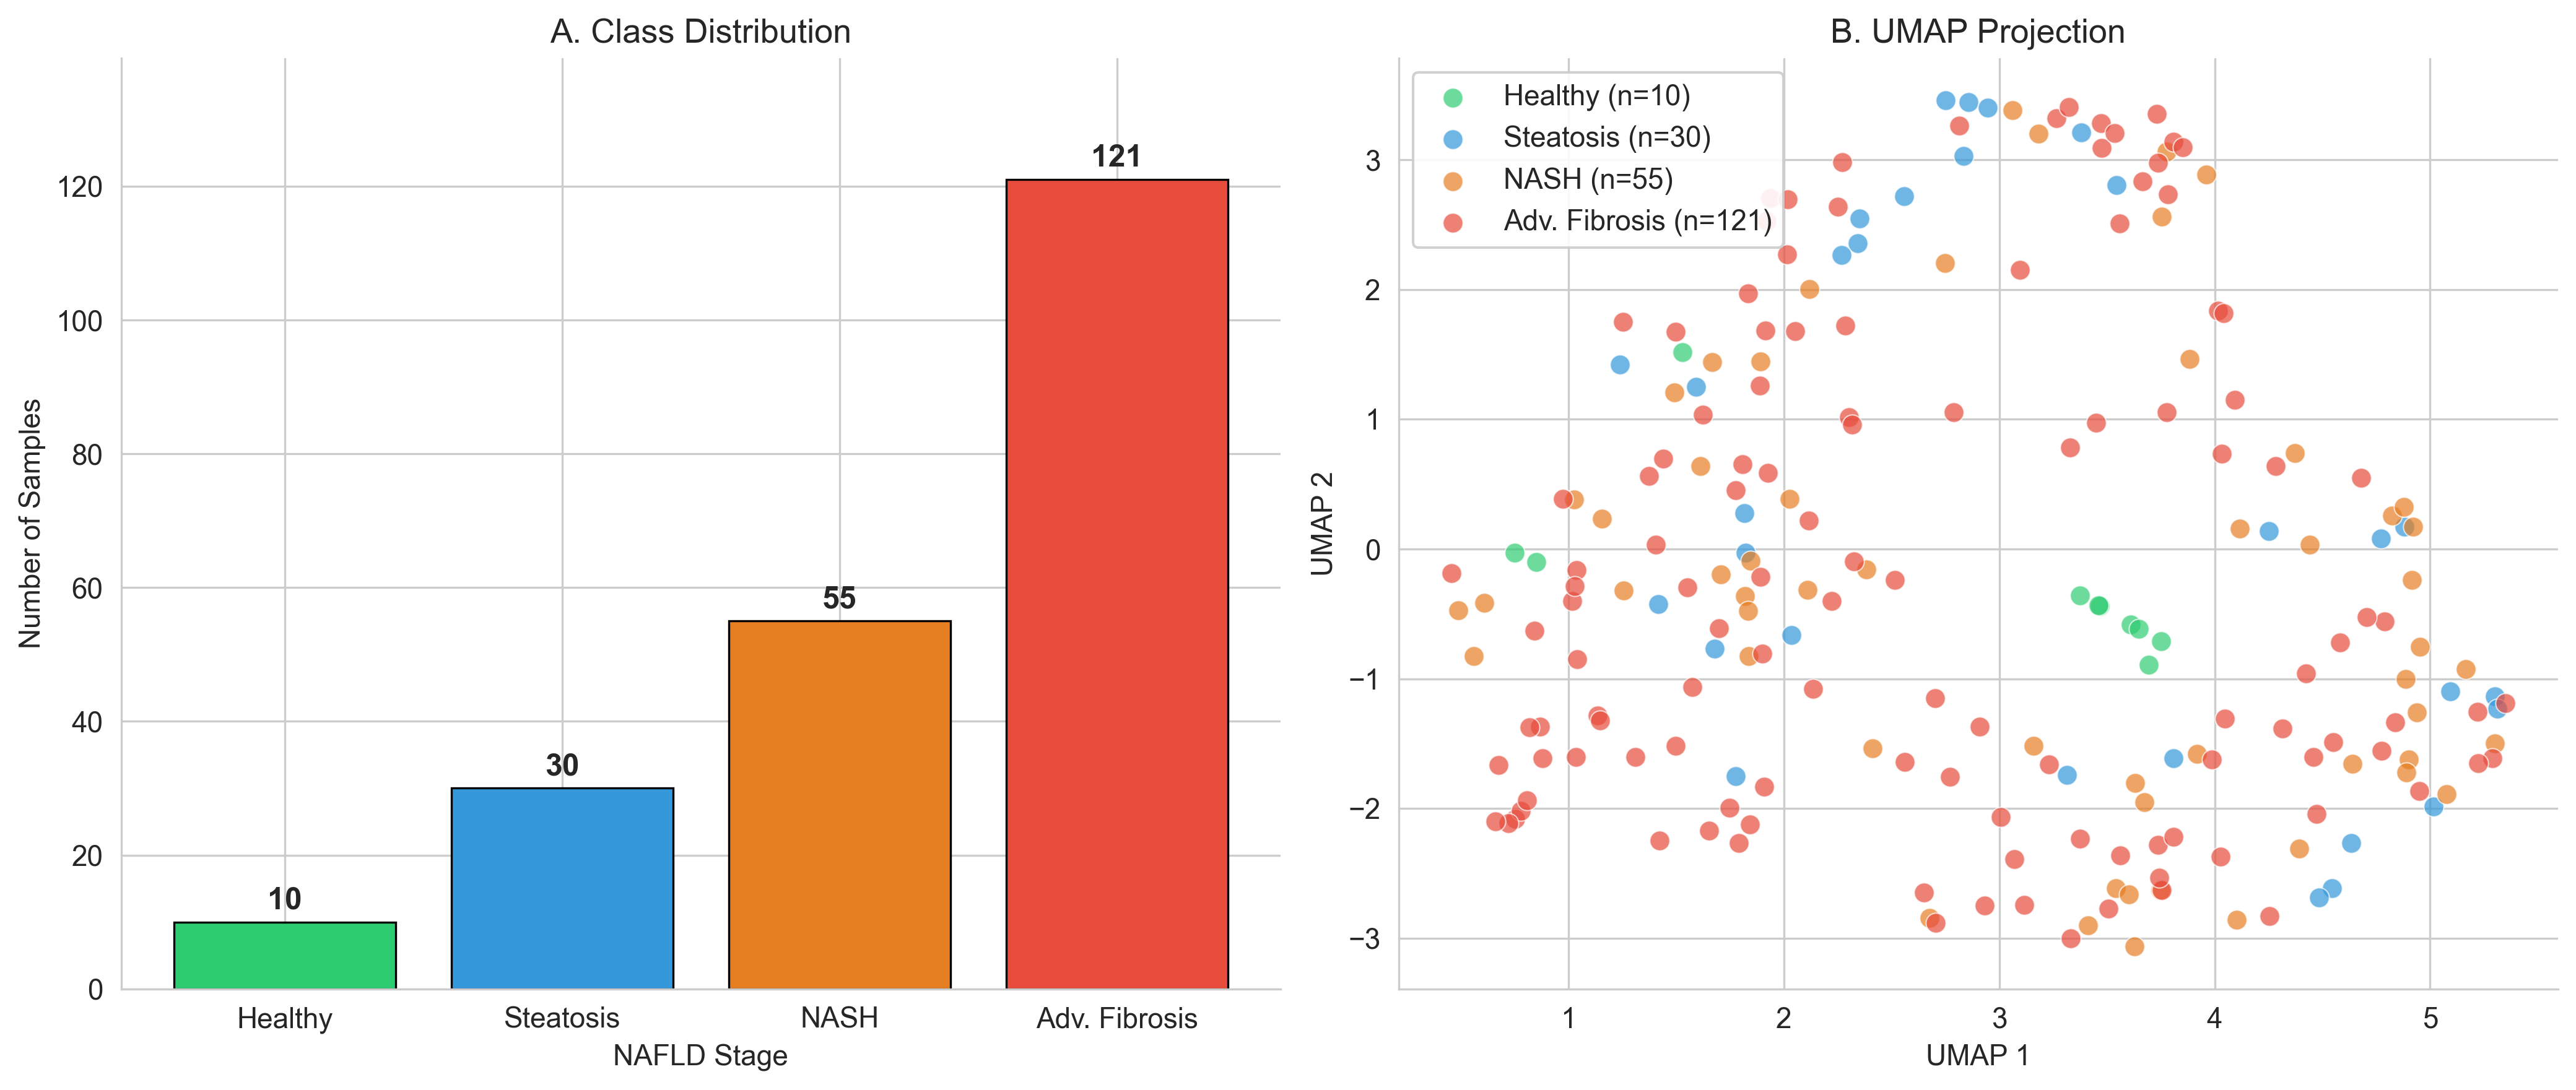

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig2_class_distribution_umap.png


In [7]:
# ### 7.1 Fig 2 — Class Distribution & UMAP

# Align samples for UMAP
common_samples = sorted(set(expression.columns) & set(metadata["sample_id"]))
expr_aligned = expression[common_samples]
meta_aligned = metadata.set_index("sample_id").loc[common_samples]

# Log2 transform for visualization
expr_log = np.log2(expr_aligned + 1)

import umap
# Compute UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
umap_coords = reducer.fit_transform(expr_log.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Class Distribution
counts = metadata["nafld_stage"].value_counts().sort_index()
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in counts.index],
    counts.values,
    color=[CLASS_COLORS[i] for i in counts.index],
    edgecolor="black",
    linewidth=0.8
)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_xlabel("NAFLD Stage")
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("A. Class Distribution")
axes[0].set_ylim(0, counts.max() * 1.15)
sns.despine(ax=axes[0])

# Panel B: UMAP
for cls_id in sorted(CLASS_NAMES.keys()):
    mask = meta_aligned["nafld_stage"].values == cls_id
    axes[1].scatter(
        umap_coords[mask, 0],
        umap_coords[mask, 1],
        c=CLASS_COLORS[cls_id],
        label=f"{CLASS_NAMES[cls_id]} (n={mask.sum()})",
        alpha=0.7,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("B. UMAP Projection")
axes[1].legend(loc="best", framealpha=0.9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig2_class_distribution_umap.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig2_class_distribution_umap.png'}")

### 7.2 PCA (Top 500 Most Variable Genes)

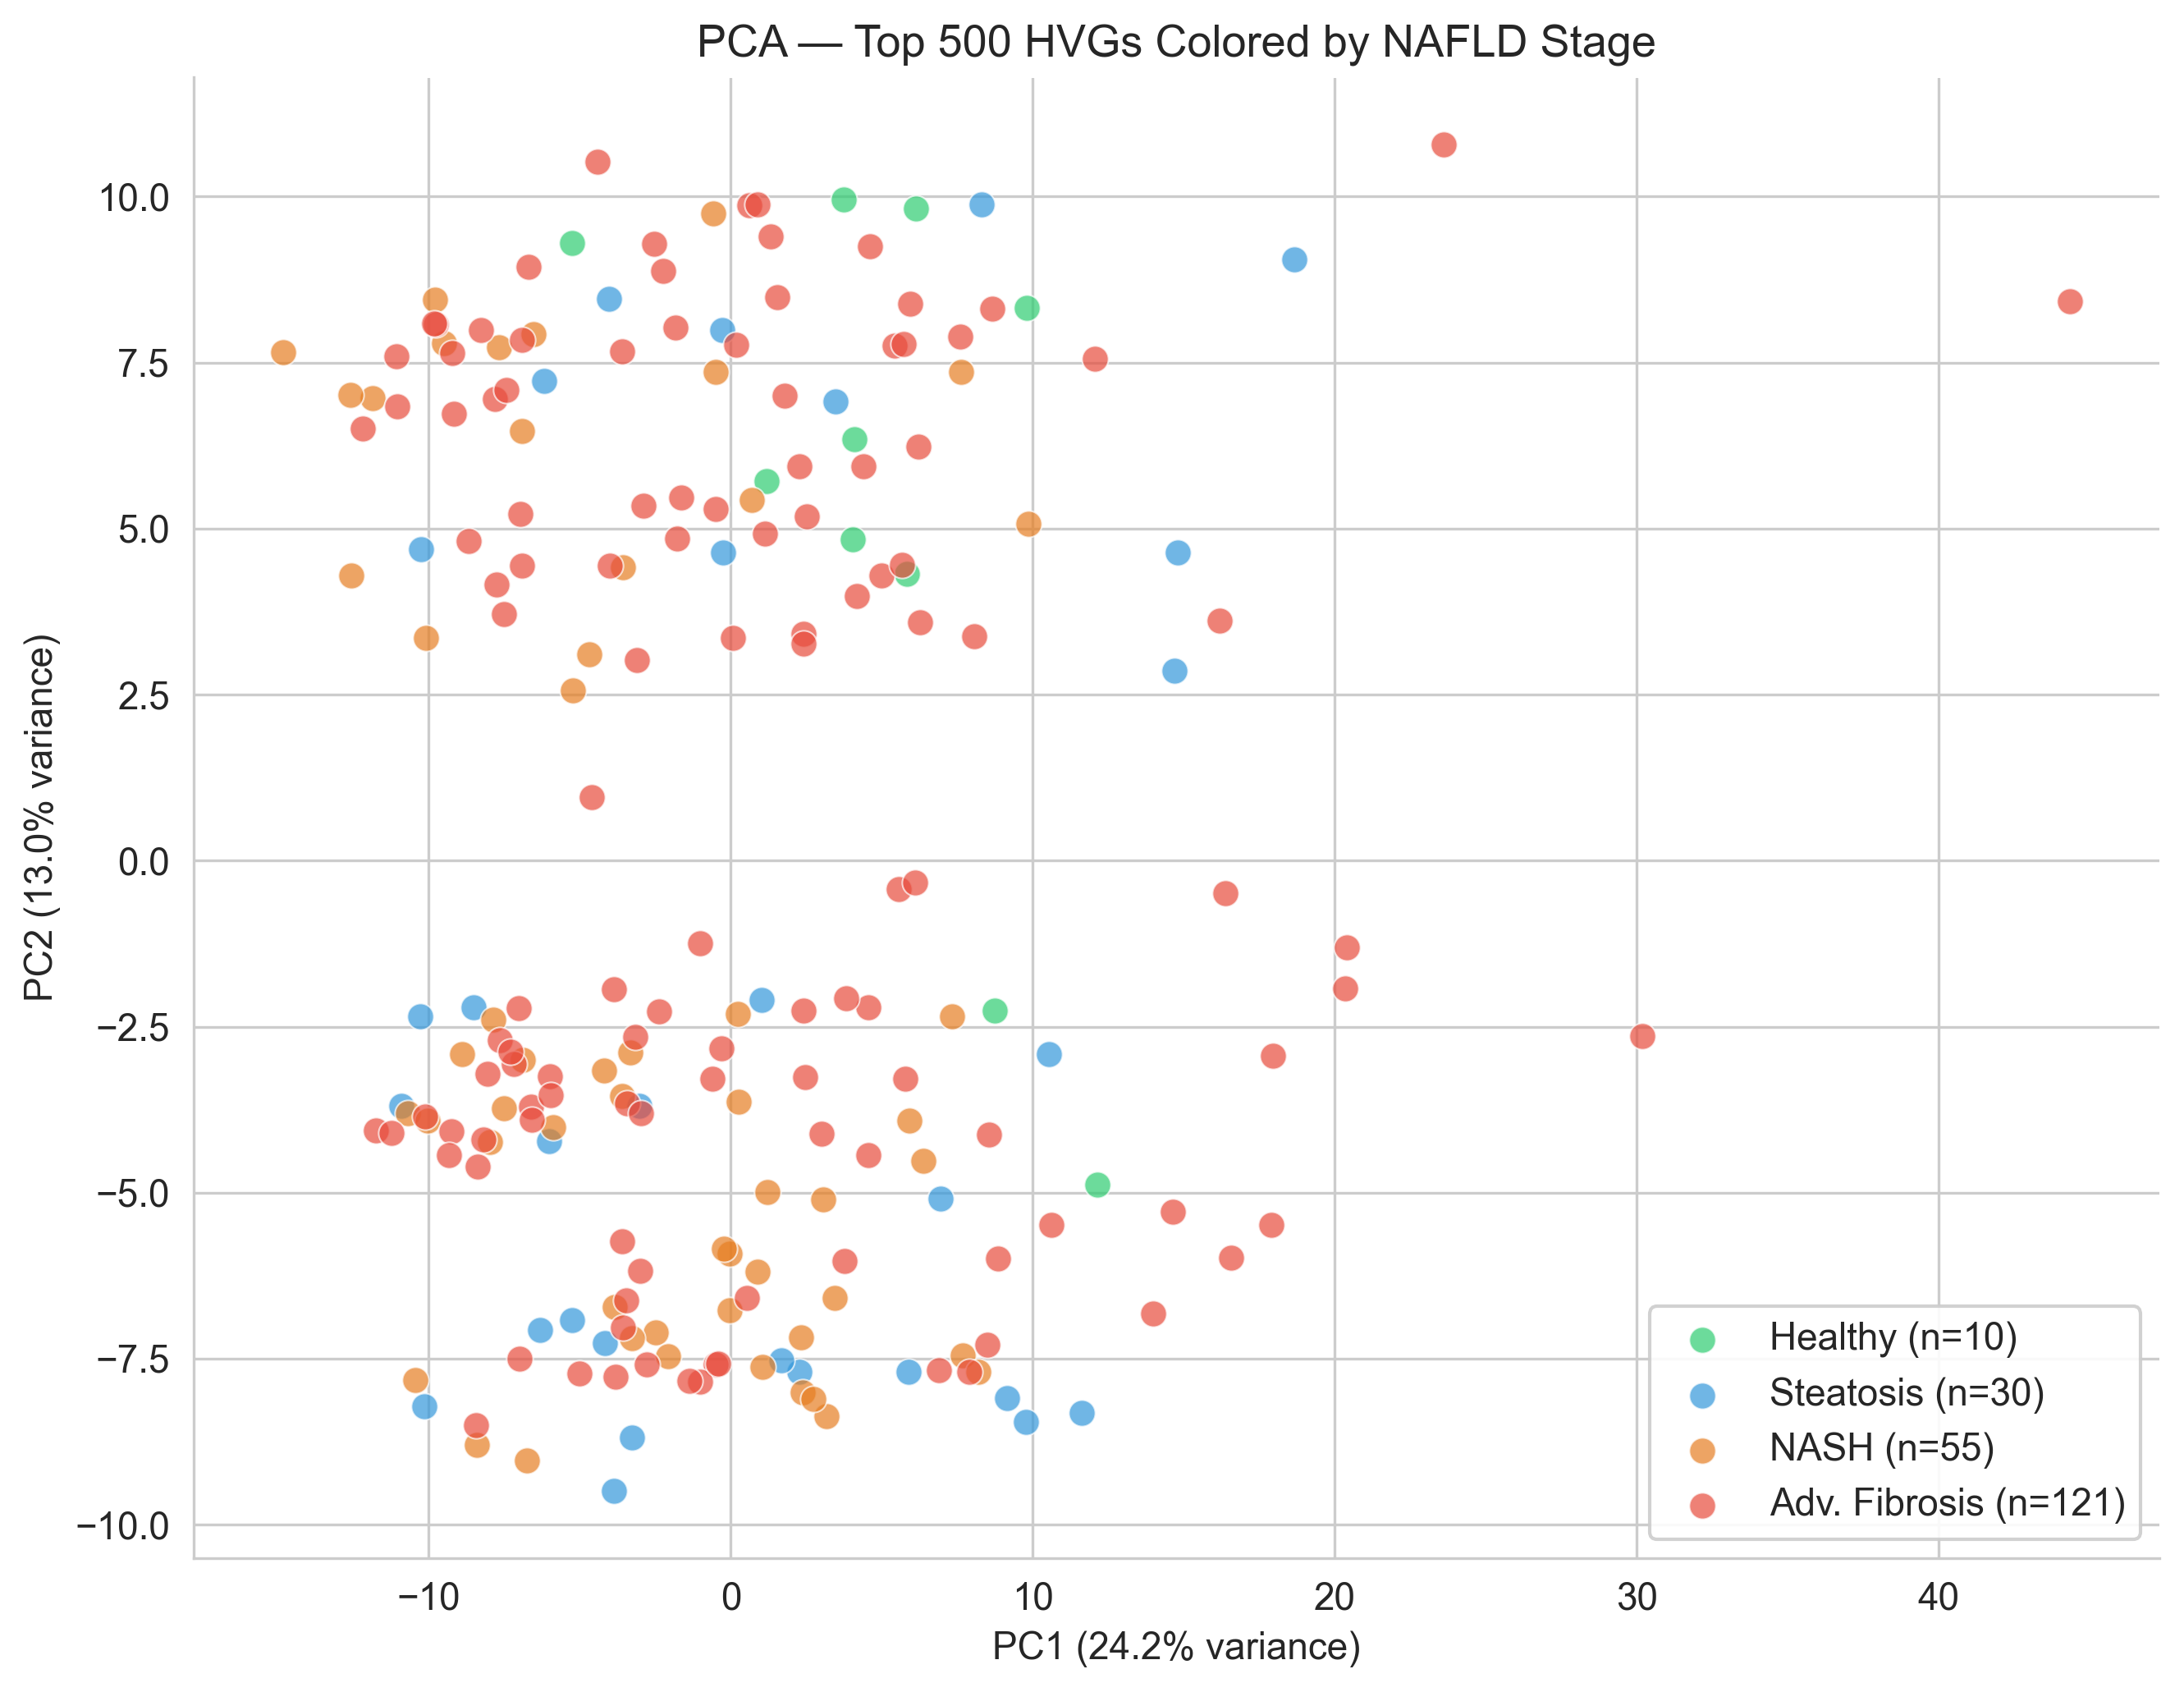

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig_eda_pca_by_stage.png


In [8]:
# Align samples
common_samples = sorted(set(expression.columns) & set(metadata["sample_id"]))
expr_aligned = expression[common_samples]
meta_aligned = metadata.set_index("sample_id").loc[common_samples]

# Select top 500 most variable genes by IQR
iqr = expr_aligned.apply(lambda x: x.quantile(0.75) - x.quantile(0.25), axis=1)
top500 = iqr.nlargest(500).index
expr_hvg = expr_aligned.loc[top500]

# Log2 transform for PCA visualization (add 1 to avoid log(0))
expr_log = np.log2(expr_hvg + 1)

# PCA
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pca_coords = pca.fit_transform(expr_log.T)  # samples in rows

fig, ax = plt.subplots(figsize=(9, 7))
for cls_id in sorted(CLASS_NAMES.keys()):
    mask = meta_aligned["nafld_stage"].values == cls_id
    ax.scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        c=CLASS_COLORS[cls_id],
        label=f"{CLASS_NAMES[cls_id]} (n={mask.sum()})",
        alpha=0.7,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA — Top 500 HVGs Colored by NAFLD Stage")
ax.legend(loc="best", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig_eda_pca_by_stage.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig_eda_pca_by_stage.png'}")


### 7.3 Heatmap — Top 50 Most Variable Genes

d:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


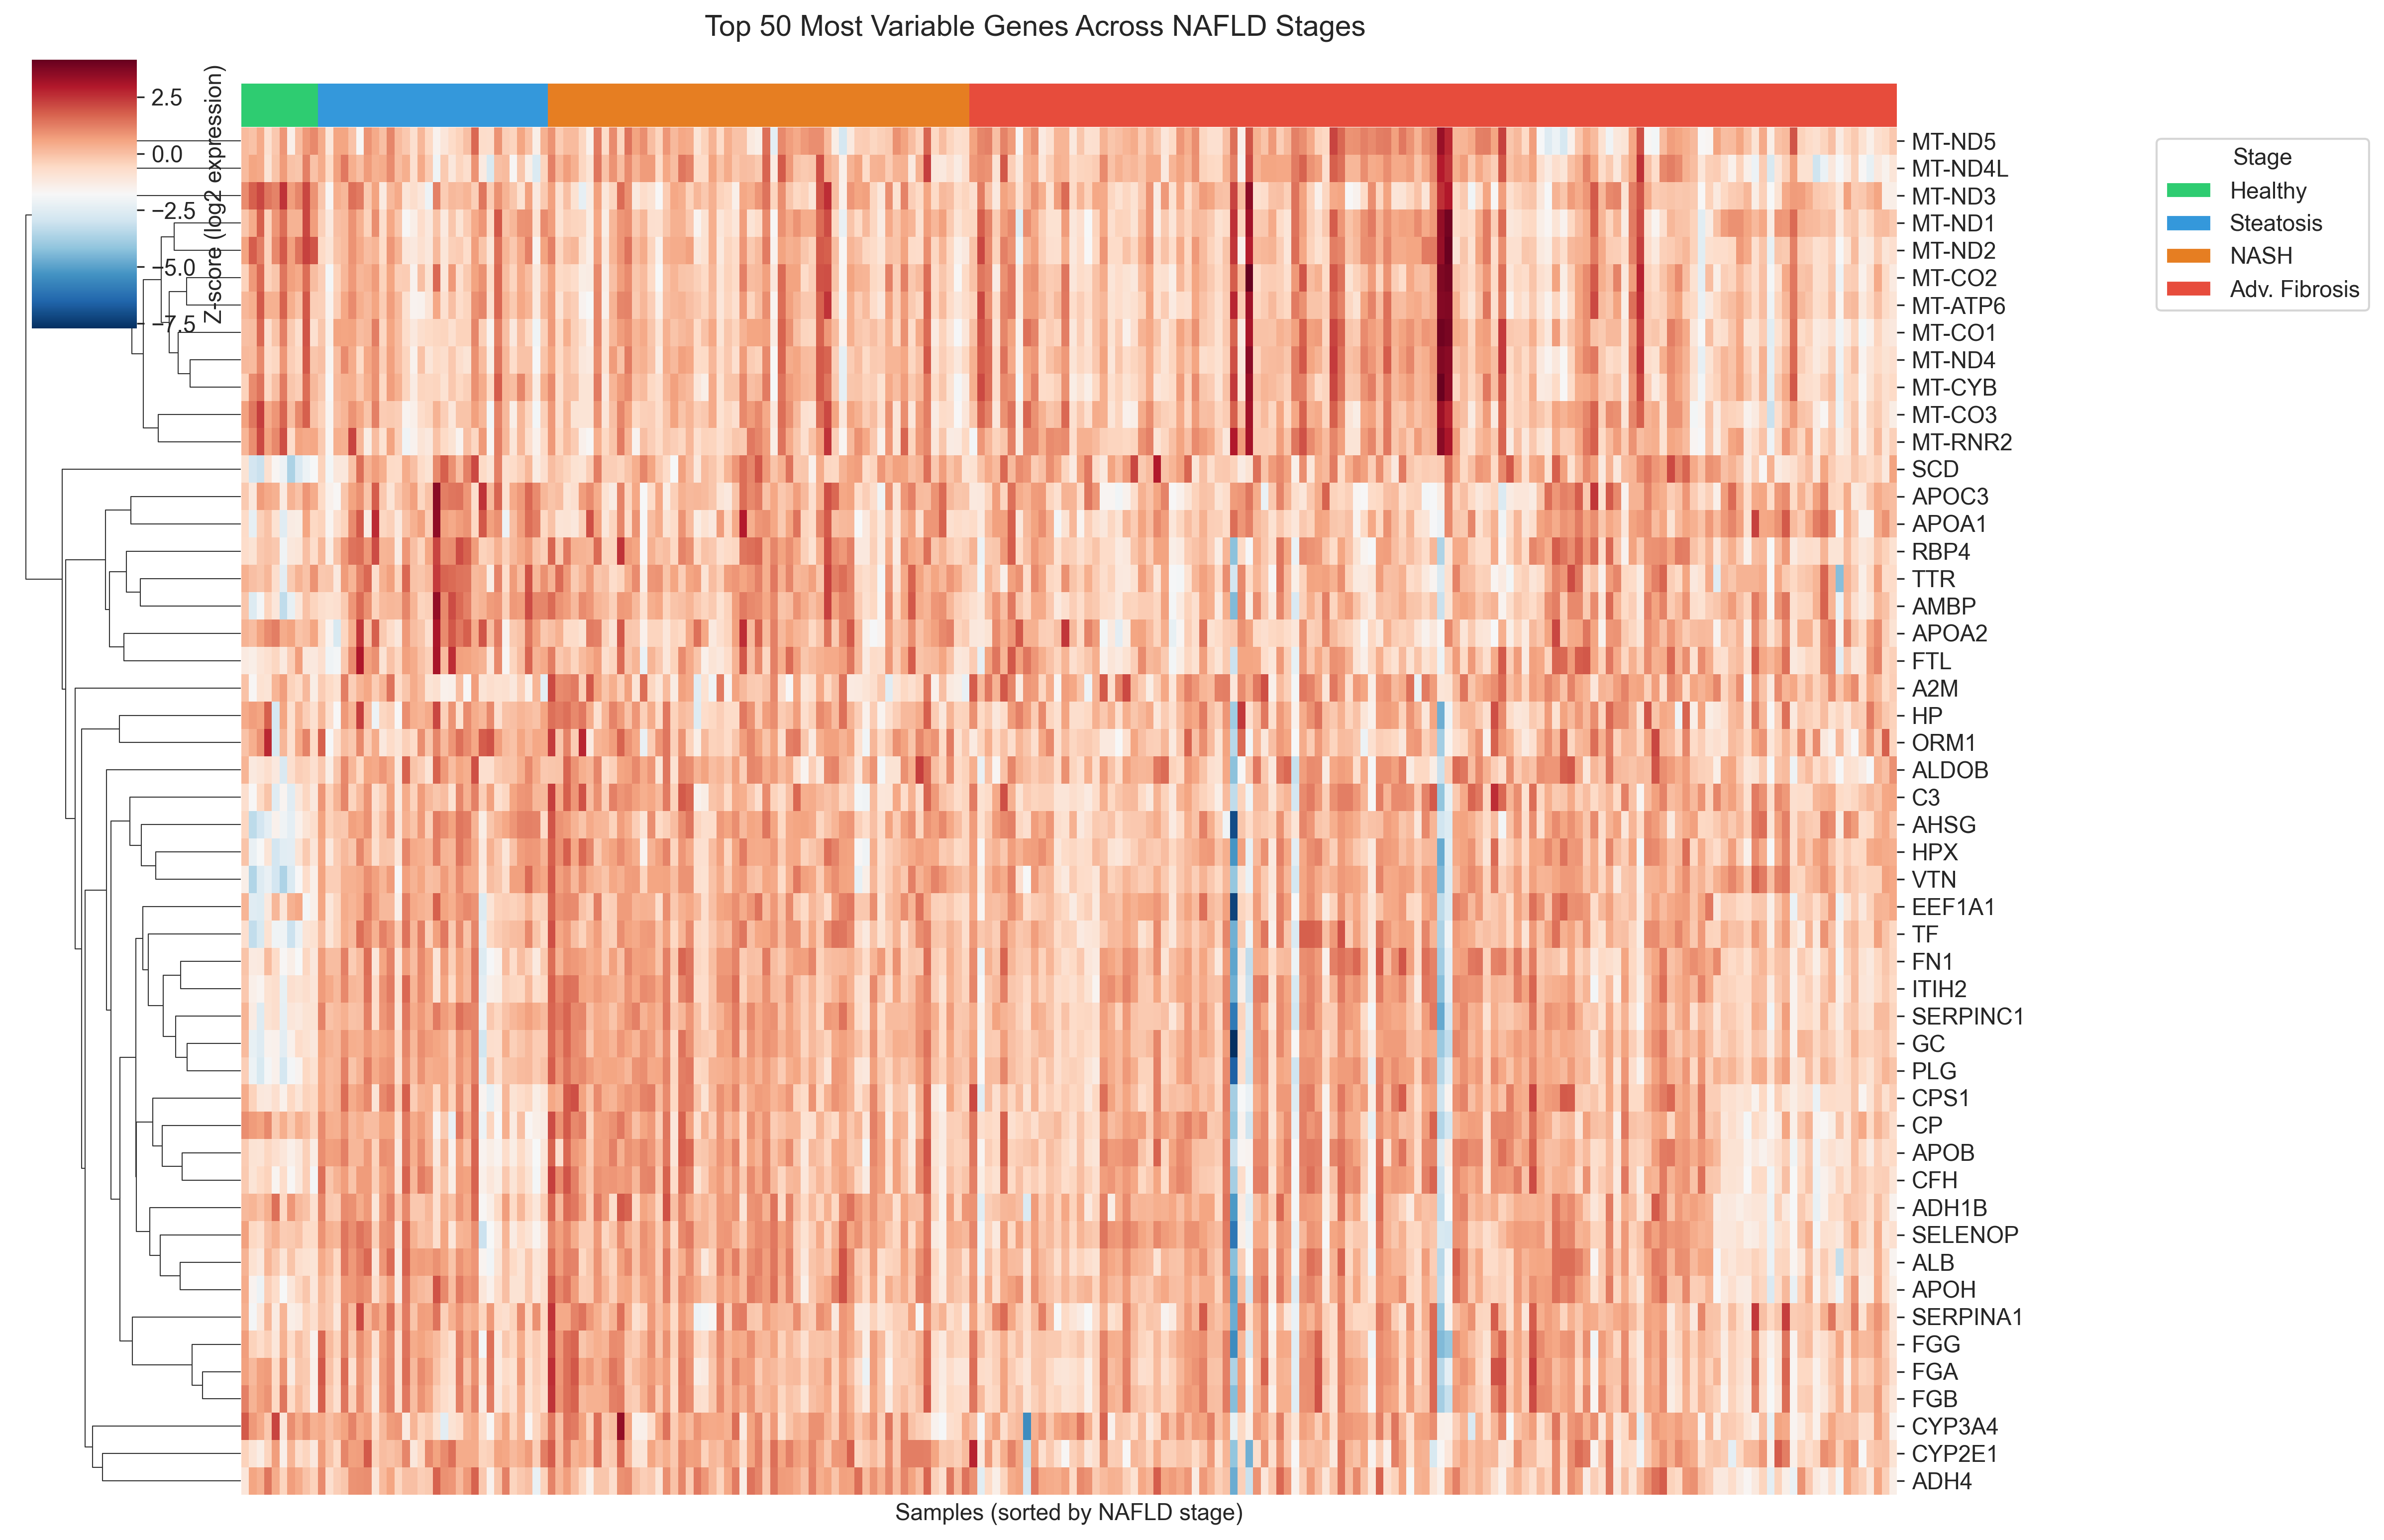

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig_eda_heatmap_top50.png


In [9]:
# Top 50 most variable genes
top50 = iqr.nlargest(50).index
expr_heatmap = np.log2(expr_aligned.loc[top50] + 1)

# Sort samples by class
sample_order = meta_aligned.sort_values("nafld_stage").index
expr_heatmap = expr_heatmap[sample_order]

# Create color bar for classes
class_series = meta_aligned.loc[sample_order, "nafld_stage"]
col_colors = class_series.map(CLASS_COLORS)

# Plot
g = sns.clustermap(
    expr_heatmap,
    col_cluster=False,    # keep class-sorted order
    row_cluster=True,     # cluster genes
    col_colors=col_colors.values,
    cmap="RdBu_r",
    z_score=0,            # z-score per gene (row)
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    linewidths=0,
    cbar_kws={"label": "Z-score (log2 expression)"},
    dendrogram_ratio=(0.12, 0.02),
)
g.ax_heatmap.set_xlabel("Samples (sorted by NAFLD stage)")
g.ax_heatmap.set_ylabel("")
g.fig.suptitle("Top 50 Most Variable Genes Across NAFLD Stages", y=1.01, fontsize=14)

# Add legend for class colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in sorted(CLASS_NAMES)]
g.ax_heatmap.legend(handles=legend_elements, loc="upper left",
                     bbox_to_anchor=(1.15, 1.0), title="Stage")

plt.savefig(RESULTS_FIG / "fig_eda_heatmap_top50.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig_eda_heatmap_top50.png'}")


### 7.4 NAS Score & Fibrosis Stage by Class

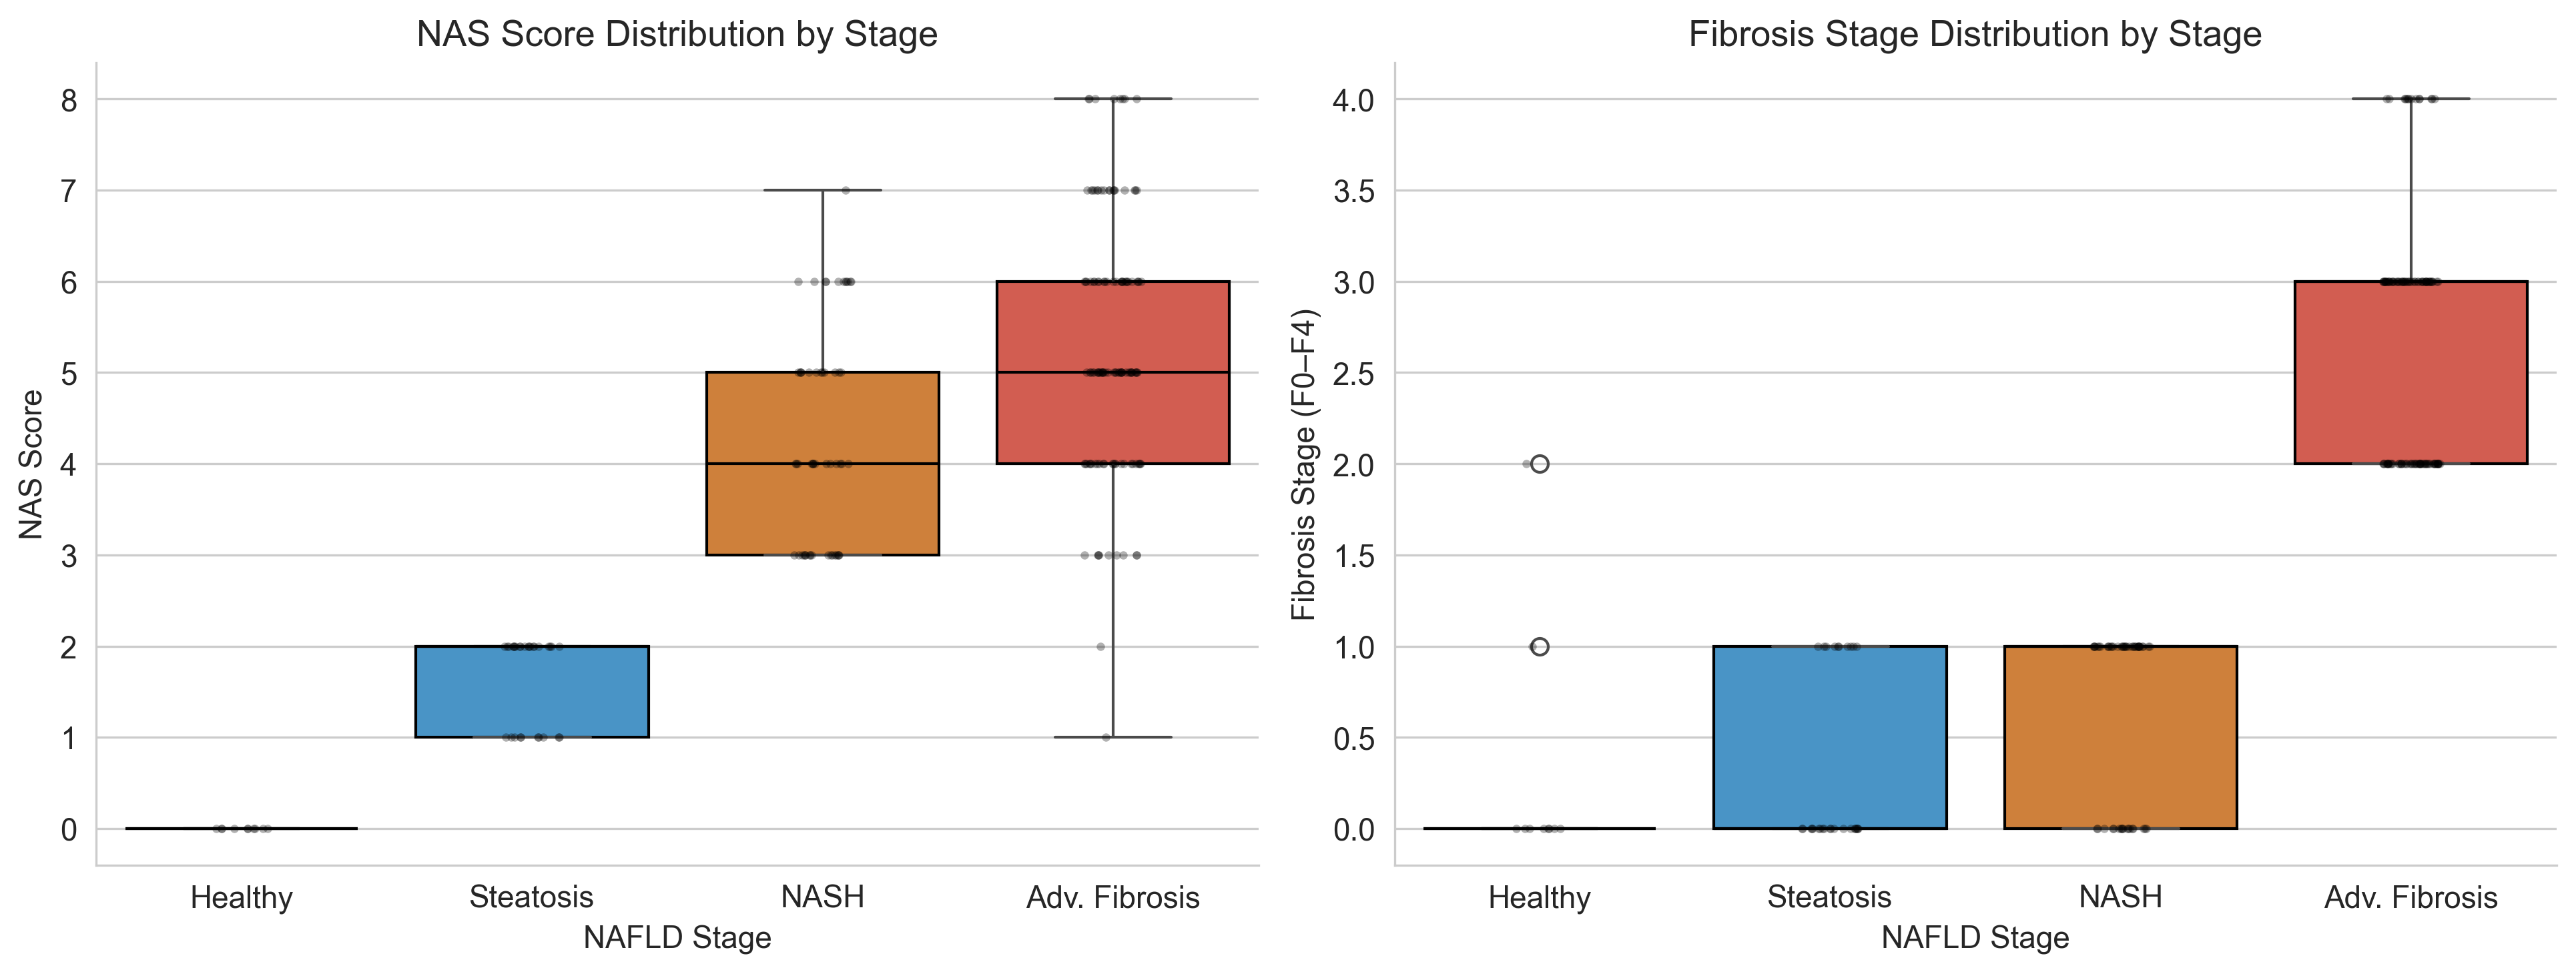

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig_eda_boxplots_nas_fibrosis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# NAS Score by class
palette = [CLASS_COLORS[i] for i in sorted(CLASS_NAMES)]
sns.boxplot(
    data=metadata, x="stage_name", y="nas score",
    order=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    palette=palette, ax=axes[0], showfliers=True,
    boxprops=dict(edgecolor="black"), medianprops=dict(color="black")
)
sns.stripplot(
    data=metadata, x="stage_name", y="nas score",
    order=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    color="black", alpha=0.3, size=3, jitter=True, ax=axes[0]
)
axes[0].set_xlabel("NAFLD Stage")
axes[0].set_ylabel("NAS Score")
axes[0].set_title("NAS Score Distribution by Stage")

# Fibrosis stage by class
sns.boxplot(
    data=metadata, x="stage_name", y="fibrosis stage",
    order=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    palette=palette, ax=axes[1], showfliers=True,
    boxprops=dict(edgecolor="black"), medianprops=dict(color="black")
)
sns.stripplot(
    data=metadata, x="stage_name", y="fibrosis stage",
    order=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    color="black", alpha=0.3, size=3, jitter=True, ax=axes[1]
)
axes[1].set_xlabel("NAFLD Stage")
axes[1].set_ylabel("Fibrosis Stage (F0–F4)")
axes[1].set_title("Fibrosis Stage Distribution by Stage")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig_eda_boxplots_nas_fibrosis.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig_eda_boxplots_nas_fibrosis.png'}")


## 8. Save Labeled Metadata

In [11]:
# Save labeled metadata
labeled_path = DATA_META / "labeled_metadata.csv"
metadata.to_csv(labeled_path, index=False)
print(f"Saved: {labeled_path}")
print(f"  Shape: {metadata.shape}")
print(f"  Columns: {metadata.columns.tolist()}")


Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\data\metadata\labeled_metadata.csv
  Shape: (216, 8)
  Columns: ['sample_id', 'nas score', 'fibrosis stage', 'group in paper', 'disease', 'stage', 'nafld_stage', 'stage_name']


## 9. Output Manifest

d:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


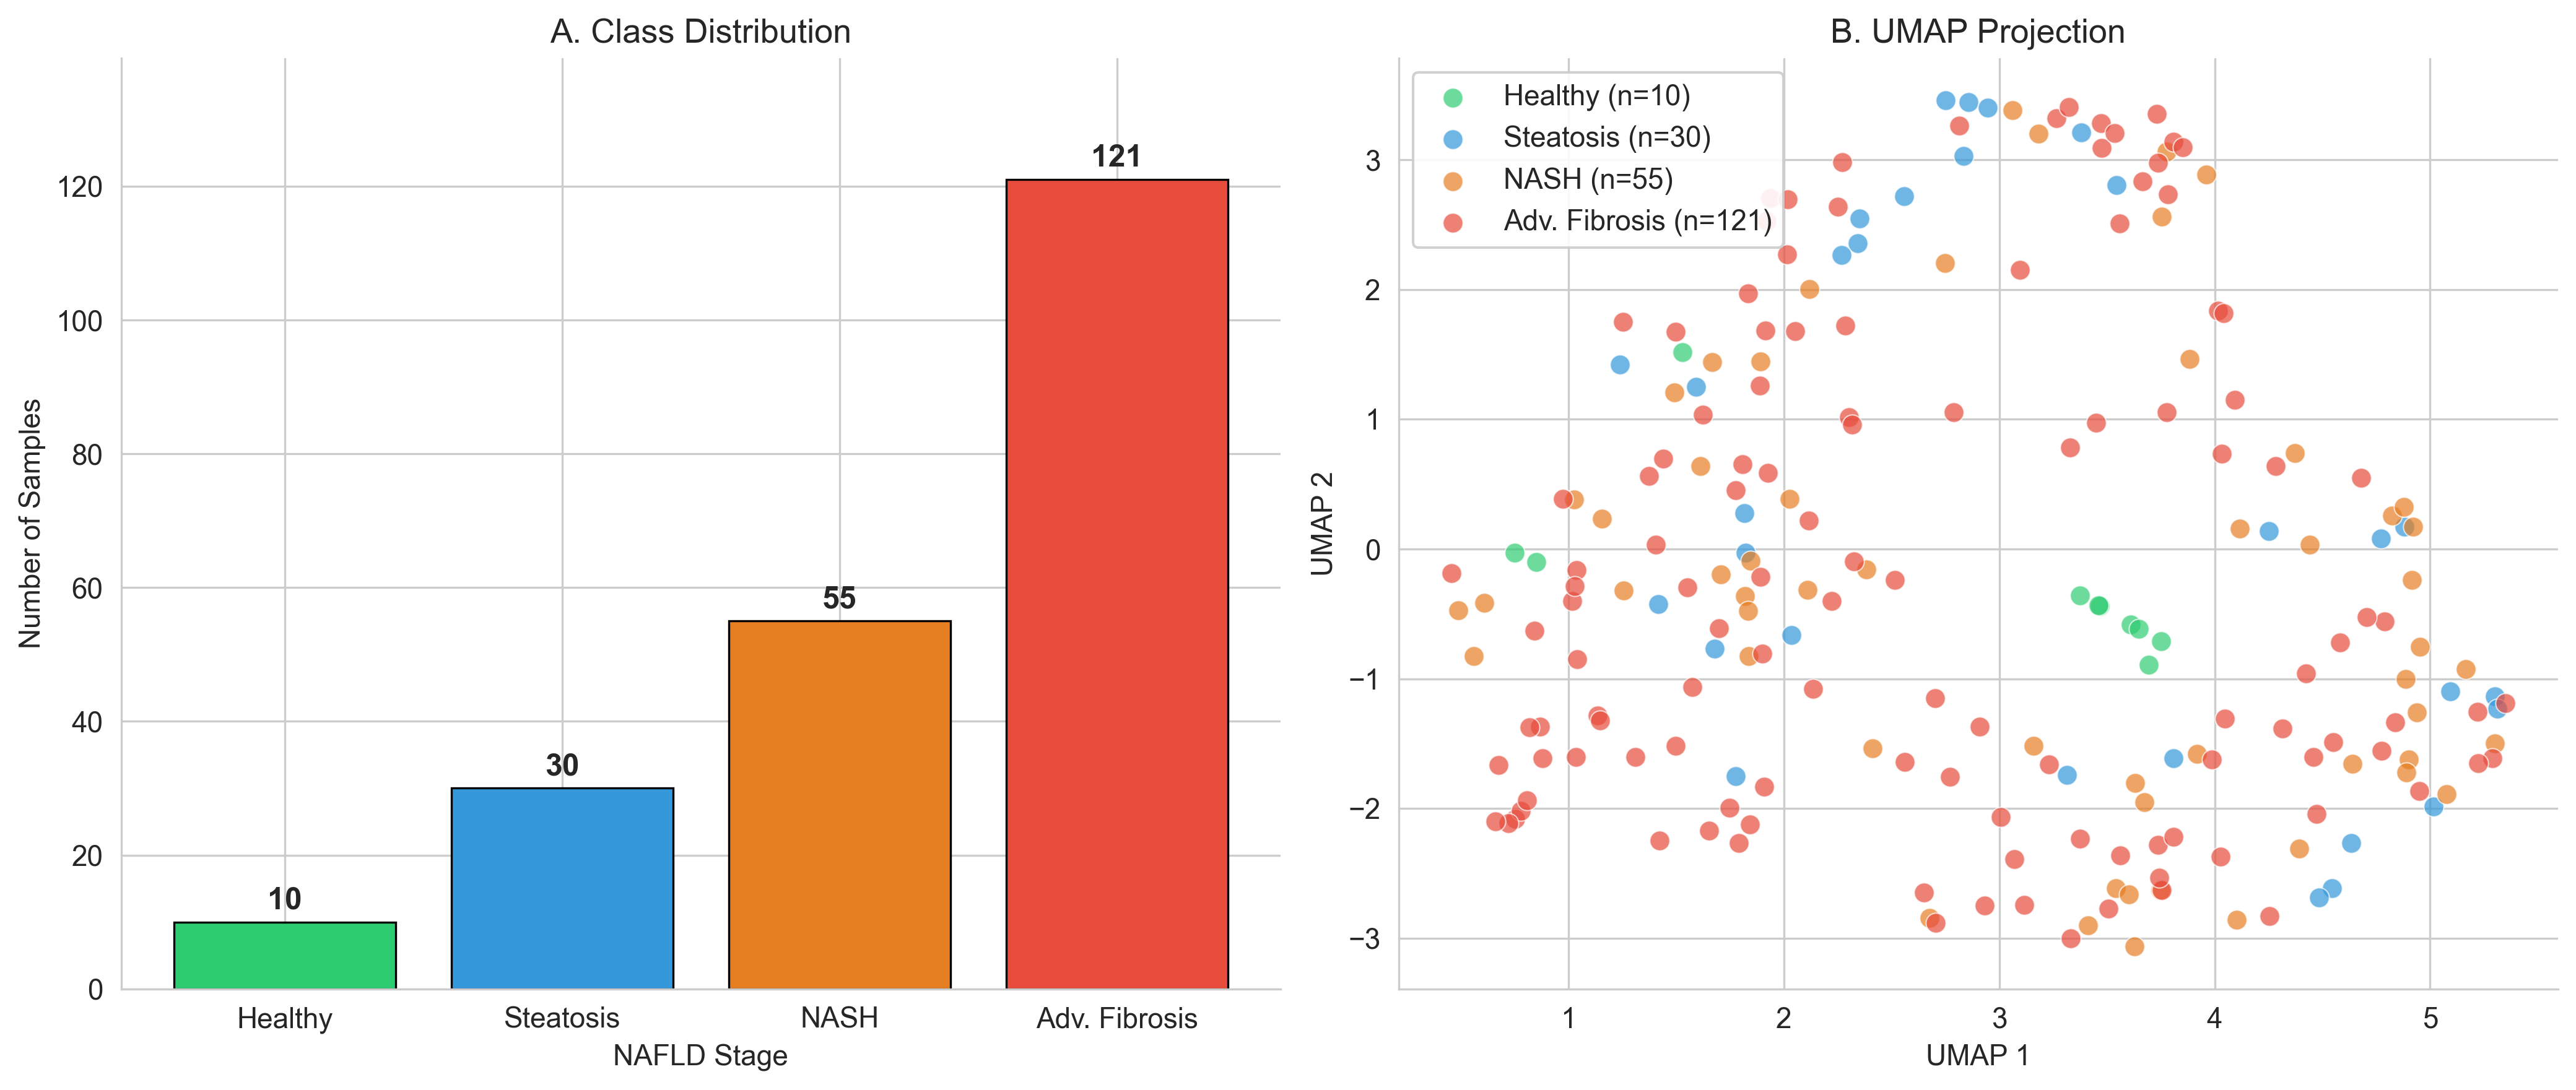

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig2_class_distribution_umap.png


In [12]:
# ### 7.1 Fig 2 — Class Distribution & UMAP

# Align samples for UMAP
common_samples = sorted(set(expression.columns) & set(metadata["sample_id"]))
expr_aligned = expression[common_samples]
meta_aligned = metadata.set_index("sample_id").loc[common_samples]

# Log2 transform for visualization
expr_log = np.log2(expr_aligned + 1)

import umap
# Compute UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
umap_coords = reducer.fit_transform(expr_log.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Class Distribution
counts = metadata["nafld_stage"].value_counts().sort_index()
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in counts.index],
    counts.values,
    color=[CLASS_COLORS[i] for i in counts.index],
    edgecolor="black",
    linewidth=0.8
)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_xlabel("NAFLD Stage")
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("A. Class Distribution")
axes[0].set_ylim(0, counts.max() * 1.15)
sns.despine(ax=axes[0])

# Panel B: UMAP
for cls_id in sorted(CLASS_NAMES.keys()):
    mask = meta_aligned["nafld_stage"].values == cls_id
    axes[1].scatter(
        umap_coords[mask, 0],
        umap_coords[mask, 1],
        c=CLASS_COLORS[cls_id],
        label=f"{CLASS_NAMES[cls_id]} (n={mask.sum()})",
        alpha=0.7,
        edgecolors="white",
        linewidths=0.5,
        s=60
    )

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("B. UMAP Projection")
axes[1].legend(loc="best", framealpha=0.9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig2_class_distribution_umap.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig2_class_distribution_umap.png'}")